In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, ImageFilter, ImageEnhance, ImageDraw

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    cohen_kappa_score, classification_report, confusion_matrix
)
from scipy.optimize import curve_fit
from tqdm import tqdm
import random
import warnings
warnings.filterwarnings('ignore')



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path   = '/content/drive/MyDrive/Dataset'
field1_path = os.path.join(base_path, 'Field Images/FieldImages-1')
field2_path = os.path.join(base_path, 'Field Images/FieldImages-2')
lab_path    = os.path.join(base_path, 'Lab Images')

Mounted at /content/drive


In [ ]:
# Field Images 1 (CSV-annotated)
disease_cols = ['GLS','NCLB','PLS','CR','SR','NoFoliarSymptoms','Other','UnidentifiedDisease']
df1 = pd.read_csv(os.path.join(field1_path, 'Corn-Annotations.csv'))
df1['label_count'] = df1[disease_cols].sum(axis=1)
df1 = df1[df1['label_count'] == 1]
def get_label(row):
    for col in disease_cols:
        if row[col] == 1: return col
df1['label'] = df1.apply(get_label, axis=1)
df1['image_path'] = df1['filePath'].apply(lambda x: os.path.join(field1_path, 'leaf_images', x))
df1['source'] = 'field'
df1 = df1[['image_path','label','source']]

# Field Images 2 (folder-structured)
data_field2 = []
for label in os.listdir(field2_path):
    cp = os.path.join(field2_path, label)
    if os.path.isdir(cp):
        for img in os.listdir(cp):
            data_field2.append([os.path.join(cp, img), label.upper(), 'field'])
df2 = pd.DataFrame(data_field2, columns=['image_path','label','source'])

# Lab Images
data_lab = []
for label in os.listdir(lab_path):
    cp = os.path.join(lab_path, label)
    if os.path.isdir(cp):
        for img in os.listdir(cp):
            data_lab.append([os.path.join(cp, img), label, 'lab'])
df3 = pd.DataFrame(data_lab, columns=['image_path','label','source'])

print(f'Field-1: {len(df1)} | Field-2: {len(df2)} | Lab: {len(df3)}')

Field-1: 1464 | Field-2: 1571 | Lab: 3852


In [ ]:
label_map = {
    'GLS': 'Gray_Leaf_Spot',
    'Corn_Cercospora_leaf_spot_Gray_leaf_spot': 'Gray_Leaf_Spot',
    'NCLB': 'Northern_Leaf_Blight',
    'NLB':  'Northern_Leaf_Blight',
    'NLS':  'Northern_Leaf_Blight',
    'Corn_Northern_Leaf_Blight': 'Northern_Leaf_Blight',
    'CR': 'Common_Rust',
    'Corn_Common_rust': 'Common_Rust',
    'NoFoliarSymptoms': 'Healthy',
    'Corn_healthy': 'Healthy',
    'PLS': 'Phaeosphaeria_Leaf_Spot',
    'SR':  'Southern_Rust',
}

def standardise(x):
    x = str(x).strip().replace('___','_').replace(' ','_')
    return label_map.get(x, x)

for d in [df1, df2, df3]:
    d['label'] = d['label'].apply(standardise)

df_all = pd.concat([df1, df2, df3], ignore_index=True)

TARGET_CLASSES = ['Northern_Leaf_Blight','Gray_Leaf_Spot','Healthy','Common_Rust']
df_all = df_all[df_all['label'].isin(TARGET_CLASSES)].reset_index(drop=True)

print('Class distribution:')
print(df_all['label'].value_counts().to_frame('count'))

Class distribution:
                      count
label                      
Northern_Leaf_Blight   2173
Gray_Leaf_Spot         1666
Healthy                1394
Common_Rust            1299


In [ ]:
# mapping
labels_sorted = sorted(df_all['label'].unique())
label_to_idx  = {l: i for i, l in enumerate(labels_sorted)}
idx_to_label  = {i: l for l, i in label_to_idx.items()}
df_all['label_idx'] = df_all['label'].map(label_to_idx)
CLASS_NAMES = labels_sorted
num_classes = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)

train_df, test_df = train_test_split(
    df_all, test_size=0.2, random_state=42, stratify=df_all['label_idx']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'\nTrain: {len(train_df)} | Test: {len(test_df)}')
print('\nTest set class distribution:')
print(test_df['label'].value_counts().to_frame('count'))

Classes: ['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Northern_Leaf_Blight']

Train: 5225 | Test: 1307

Test set class distribution:
                      count
label                      
Northern_Leaf_Blight    435
Gray_Leaf_Spot          333
Healthy                 279
Common_Rust             260


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model_path = '/content/drive/MyDrive/resnet_4class.pth'
checkpoint = torch.load(model_path, map_location=device)

class_to_idx_ckpt = checkpoint['class_to_idx']
idx_to_class_ckpt = {v: k for k, v in class_to_idx_ckpt.items()}
num_classes_ckpt  = checkpoint['num_classes']

model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes_ckpt)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print('Model loaded. Classes:', idx_to_class_ckpt)

Device: cpu
Model loaded. Classes: {0: 'Common_Rust', 1: 'Gray_Leaf_Spot', 2: 'Healthy', 3: 'Northern_Leaf_Blight'}


In [ ]:

label_to_idx = class_to_idx_ckpt
idx_to_label = idx_to_class_ckpt
CLASS_NAMES  = [idx_to_label[i] for i in range(num_classes_ckpt)]
test_df['label_idx'] = test_df['label'].map(label_to_idx)
test_df = test_df.dropna(subset=['label_idx'])
test_df['label_idx'] = test_df['label_idx'].astype(int)
print('Aligned CLASS_NAMES:', CLASS_NAMES)

Aligned CLASS_NAMES: ['Common_Rust', 'Gray_Leaf_Spot', 'Healthy', 'Northern_Leaf_Blight']


In [ ]:
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def compute_all_metrics(true_labels, pred_labels, class_names):
    """
    Returns a dict with all required metrics:
    accuracy, macro_f1, weighted_f1, precision (macro), recall (macro),
    cohen_kappa, per_class_f1, confusion_matrix
    """
    acc     = accuracy_score(true_labels, pred_labels)
    macro_f1   = f1_score(true_labels, pred_labels, average='macro',    zero_division=0)
    weighted_f1= f1_score(true_labels, pred_labels, average='weighted', zero_division=0)
    prec    = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    rec     = recall_score(true_labels, pred_labels, average='macro',    zero_division=0)
    kappa   = cohen_kappa_score(true_labels, pred_labels)
    per_class_f1 = f1_score(true_labels, pred_labels, average=None,
                            labels=list(range(len(class_names))), zero_division=0)
    cm = confusion_matrix(true_labels, pred_labels,
                          labels=list(range(len(class_names))))
    return {
        'accuracy':     acc,
        'macro_f1':     macro_f1,
        'weighted_f1':  weighted_f1,
        'precision':    prec,
        'recall':       rec,
        'kappa':        kappa,
        'per_class_f1': per_class_f1.tolist(),
        'confusion_matrix': cm.tolist(),
    }

def run_inference(df, noise_fn=None, intensity=None):
    """
    Run model on every image in df, optionally applying noise.
    Returns (true_labels_list, pred_labels_list).
    """
    model.eval()
    all_true, all_pred = [], []

    for i in range(len(df)):
        img_path = df.iloc[i]['image_path']
        true_idx = df.iloc[i]['label_idx']

        img = Image.open(img_path).convert('RGB')
        if noise_fn is not None:
            img = noise_fn(img, intensity)

        x = eval_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            out  = model(x)
            pred = torch.argmax(out, dim=1).item()

        all_true.append(true_idx)
        all_pred.append(pred)

    return all_true, all_pred

print('Helpers defined.')

Helpers defined.


In [ ]:
def gaussian_blur(img, intensity):
    return img.filter(ImageFilter.GaussianBlur(radius=intensity))

def brightness_shift(img, intensity):
    return ImageEnhance.Brightness(img).enhance(1 + intensity)

def occlusion(img, intensity):
    img = img.copy()
    w, h = img.size
    draw = ImageDraw.Draw(img)
    fraction = min(intensity / 10, 0.9)
    area = int(w * h * fraction)
    covered = 0
    rng = random.Random(42)
    while covered < area:
        rw = rng.randint(20, int(w * 0.2))
        rh = rng.randint(20, int(h * 0.2))
        x  = rng.randint(0, w - rw)
        y  = rng.randint(0, h - rh)
        draw.rectangle([x, y, x+rw, y+rh], fill=(0,0,0))
        covered += rw * rh
    return img

def rotation(img, intensity):
    return img.rotate(intensity)

NOISE_FUNCS = {
    'blur':       gaussian_blur,
    'brightness': brightness_shift,
    'occlusion':  occlusion,
    'rotation':   rotation,
}

INTENSITIES = {
    'blur':       [1, 3, 5, 9, 15],
    'brightness': [-0.9, -0.6, 0.6, 0.9, 2.0],
    'occlusion':  [1, 3, 5, 8, 10],
    'rotation':   [15, 30, 45, 90, 100],
}

print('Noise functions defined.')

Noise functions defined.


In [ ]:
print('Running baseline (clean) evaluation...')
true_clean, pred_clean = run_inference(test_df)
baseline_metrics = compute_all_metrics(true_clean, pred_clean, CLASS_NAMES)

print('\n=== BASELINE RESULTS (Clean) ===')
print(f"  Accuracy:         {baseline_metrics['accuracy']:.4f}")
print(f"  Macro-F1:         {baseline_metrics['macro_f1']:.4f}")
print(f"  Weighted-F1:      {baseline_metrics['weighted_f1']:.4f}")
print(f"  Precision (macro):{baseline_metrics['precision']:.4f}")
print(f"  Recall (macro):   {baseline_metrics['recall']:.4f}")
print(f"  Cohen's Kappa:    {baseline_metrics['kappa']:.4f}")
print()
print('Per-class F1:')
for cls, f1 in zip(CLASS_NAMES, baseline_metrics['per_class_f1']):
    print(f'  {cls:<30} {f1:.4f}')

A0_acc     = baseline_metrics['accuracy']
A0_macro_f1= baseline_metrics['macro_f1']

Running baseline (clean) evaluation...

=== BASELINE RESULTS (Clean) ===
  Accuracy:         0.9702
  Macro-F1:         0.9703
  Weighted-F1:      0.9700
  Precision (macro):0.9699
  Recall (macro):   0.9712
  Cohen's Kappa:    0.9596

Per-class F1:
  Common_Rust                    0.9866
  Gray_Leaf_Spot                 0.9508
  Healthy                        0.9667
  Northern_Leaf_Blight           0.9771


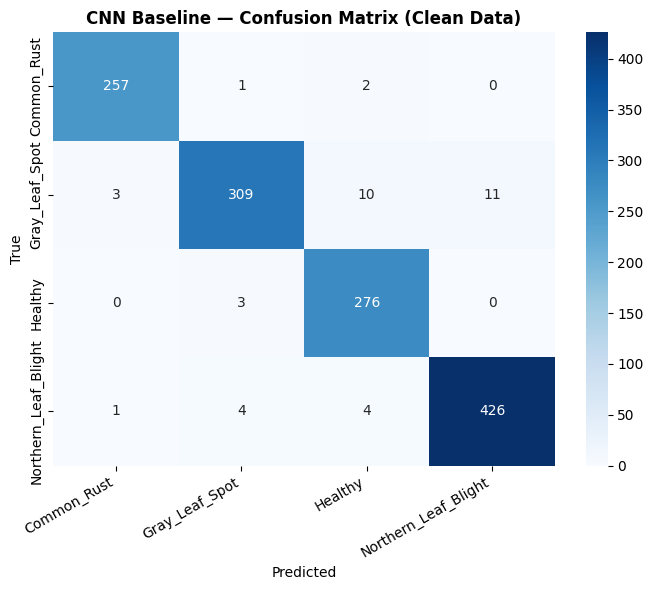


Full Classification Report:
                      precision    recall  f1-score   support

         Common_Rust       0.98      0.99      0.99       260
      Gray_Leaf_Spot       0.97      0.93      0.95       333
             Healthy       0.95      0.99      0.97       279
Northern_Leaf_Blight       0.97      0.98      0.98       435

            accuracy                           0.97      1307
           macro avg       0.97      0.97      0.97      1307
        weighted avg       0.97      0.97      0.97      1307



In [ ]:
# Baseline Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = np.array(baseline_metrics['confusion_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title('CNN Baseline — Confusion Matrix (Clean Data)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_confusion_baseline.png', dpi=150)
plt.show()

print('\nFull Classification Report:')
label_names = [idx_to_label[i] for i in range(len(CLASS_NAMES))]
print(classification_report(true_clean, pred_clean, target_names=label_names, zero_division=0))

In [ ]:
from datetime import datetime

noise_results = {}

for noise_name, noise_fn in NOISE_FUNCS.items():
    noise_results[noise_name] = {}
    print(f'\n--- Noise: {noise_name} ---')

    for intensity in tqdm(INTENSITIES[noise_name], desc=noise_name):
        true_list, pred_list = run_inference(test_df, noise_fn=noise_fn, intensity=intensity)
        m = compute_all_metrics(true_list, pred_list, CLASS_NAMES)
        m['true_labels'] = true_list
        m['pred_labels'] = pred_list
        noise_results[noise_name][intensity] = m
        print(f'  {noise_name} I={intensity}: acc={m["accuracy"]:.4f}  macro_f1={m["macro_f1"]:.4f}  kappa={m["kappa"]:.4f}')

print('\nAll noise evaluations complete!')


--- Noise: blur ---


blur:  20%|██        | 1/5 [11:14<44:59, 674.77s/it]

  blur I=1: acc=0.9656  macro_f1=0.9659  kappa=0.9534


blur:  40%|████      | 2/5 [22:33<33:50, 676.97s/it]

  blur I=3: acc=0.8669  macro_f1=0.8664  kappa=0.8210


...

  rotation I=45: acc=0.9013  macro_f1=0.8980  kappa=0.8677


rotation:  80%|████████  | 4/5 [30:22<07:35, 455.86s/it]

  rotation I=90: acc=0.9357  macro_f1=0.9333  kappa=0.9132


rotation: 100%|██████████| 5/5 [38:22<00:00, 460.49s/it]

  rotation I=100: acc=0.9174  macro_f1=0.9140  kappa=0.8888

All noise evaluations complete!


In [ ]:
import numpy as np

def make_serializable(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, list):
        return [make_serializable(i) for i in obj]
    elif isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    return obj


save_dict = {}
for noise, intensities in noise_results.items():
    save_dict[noise] = {}
    for intens, m in intensities.items():
        save_dict[noise][str(intens)] = make_serializable({
            k: v for k, v in m.items()
            if k not in ('confusion_matrix',)
        })

with open('/content/drive/MyDrive/cnn_noise_results_full.json', 'w') as f:
    json.dump(save_dict, f, indent=2)
print('Saved to Drive.')

Saved to Drive.


In [ ]:
rows = []
for noise, intensities in noise_results.items():
    for intens, m in intensities.items():
        row = {
            'Noise':       noise,
            'Intensity':   intens,
            'Accuracy':    m['accuracy'],
            'Macro_F1':    m['macro_f1'],
            'Weighted_F1': m['weighted_f1'],
            'Precision':   m['precision'],
            'Recall':      m['recall'],
            'Kappa':       m['kappa'],
        }
        for cls, f1_val in zip(CLASS_NAMES, m['per_class_f1']):
            row[f'F1_{cls}'] = f1_val
        rows.append(row)

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

     Noise  Intensity  Accuracy  Macro_F1  Weighted_F1  Precision   Recall    Kappa  F1_Common_Rust  F1_Gray_Leaf_Spot  F1_Healthy  F1_Northern_Leaf_Blight
      blur        1.0  0.965570  0.965897     0.965228   0.966839 0.966415 0.953408        0.986616           0.940252    0.965035                 0.971687
      blur        3.0  0.866871  0.866400     0.866150   0.888827 0.875169 0.820998        0.972973           0.777577    0.807018                 0.908033
      blur        5.0  0.712318  0.726313     0.730343   0.832405 0.725181 0.618241        0.797267           0.718929    0.617778                 0.771277
      blur        9.0  0.575363  0.571168     0.591423   0.807547 0.579091 0.441237        0.404834           0.692607    0.508660                 0.678571
      blur       15.0  0.512624  0.477635     0.508766   0.771292 0.509129 0.358680        0.185567           0.582278    0.476027                 0.666667
brightness       -0.9  0.900536  0.906440     0.899840   0.90415

In [ ]:

def exp_decay(I, k):
    return A0_macro_f1 * np.exp(-k * I)

decay_params = {}

print('Fitting A(I) = A0 * exp(-kI) on Macro-F1')
print('=' * 55)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    I = df_n['Intensity'].values.astype(float)
    A = df_n['Macro_F1'].values.astype(float)

    try:
        popt, _ = curve_fit(exp_decay, I, A, p0=[0.1], bounds=(0, 100), maxfev=10000)
        k_fit = popt[0]
        A_pred = exp_decay(I, k_fit)
        ss_res = np.sum((A - A_pred)**2)
        ss_tot = np.sum((A - np.mean(A))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        decay_params[noise] = {'A0': A0_macro_f1, 'k': k_fit, 'R2': r2}
        print(f'{noise:<12}  A0={A0_macro_f1:.4f}  k={k_fit:.4f}  R²={r2:.4f}')
    except Exception as e:
        print(f'{noise:<12}  Fitting failed: {e}')
        decay_params[noise] = {'A0': A0_macro_f1, 'k': None, 'R2': None}

Fitting A(I) = A0 * exp(-kI) on Macro-F1
blur          A0=0.9703  k=0.0513  R²=0.9622
brightness    A0=0.9703  k=0.1469  R²=0.2795
occlusion     A0=0.9703  k=0.1013  R²=0.9657
rotation      A0=0.9703  k=0.0007  R²=-0.7795


In [ ]:
THRESHOLD = 0.70
critical_thresholds = {}

print(f'Critical thresholds (Macro-F1 < {THRESHOLD})')
print('=' * 45)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    threshold_found = None
    for _, row in df_n.iterrows():
        if row['Macro_F1'] < THRESHOLD:
            threshold_found = row['Intensity']
            break
    critical_thresholds[noise] = threshold_found
    status = f'I = {threshold_found}' if threshold_found is not None else 'Never drops below threshold'
    print(f'{noise:<12}  {status}')

Critical thresholds (Macro-F1 < 0.7)
blur          I = 9.0
brightness    I = 2.0
occlusion     I = 5.0
rotation      Never drops below threshold


In [ ]:
mpc_results = {}

print('mPC Results (average drop from baseline across all intensities)')
print('=' * 65)

for noise in df_results['Noise'].unique():
    df_n = df_results[df_results['Noise'] == noise]

    # Global mPC
    mpc_acc     = (A0_acc      - df_n['Accuracy']).mean()
    mpc_macro_f1= (A0_macro_f1 - df_n['Macro_F1']).mean()

    # Per-class mPC
    per_class_mpc = {}
    for cls in CLASS_NAMES:
        col = f'F1_{cls}'
        baseline_cls_f1 = baseline_metrics['per_class_f1'][CLASS_NAMES.index(cls)]
        per_class_mpc[cls] = (baseline_cls_f1 - df_n[col]).mean()

    mpc_results[noise] = {
        'mPC_accuracy':  mpc_acc,
        'mPC_macro_f1':  mpc_macro_f1,
        'per_class_mpc': per_class_mpc,
    }

    print(f'\n{noise}')
    print(f'  Global mPC (Accuracy):  {mpc_acc:.4f}')
    print(f'  Global mPC (Macro-F1):  {mpc_macro_f1:.4f}')
    print('  Per-class mPC (F1 drop):')
    for cls, drop in per_class_mpc.items():
        print(f'    {cls:<30} {drop:.4f}')

mPC Results (average drop from baseline across all intensities)

blur
  Global mPC (Accuracy):  0.2436
  Global mPC (Macro-F1):  0.2488
  Per-class mPC (F1 drop):
    Common_Rust                    0.3171
    Gray_Leaf_Spot                 0.2084
    Healthy                        0.2918
    Northern_Leaf_Blight           0.1778

brightness
  Global mPC (Accuracy):  0.1285
  Global mPC (Macro-F1):  0.1317
  Per-class mPC (F1 drop):
    Common_Rust                    0.0518
    Gray_Leaf_Spot                 0.1633
    Healthy                        0.1232
    Northern_Leaf_Blight           0.1886

occlusion
  Global mPC (Accuracy):  0.3474
  Global mPC (Macro-F1):  0.3686
  Per-class mPC (F1 drop):
    Common_Rust                    0.0385
    Gray_Leaf_Spot                 0.3404
    Healthy                        0.4717
    Northern_Leaf_Blight           0.6236

rotation
  Global mPC (Accuracy):  0.0445
  Global mPC (Macro-F1):  0.0469
  Per-class mPC (F1 drop):
    Common_Rust      

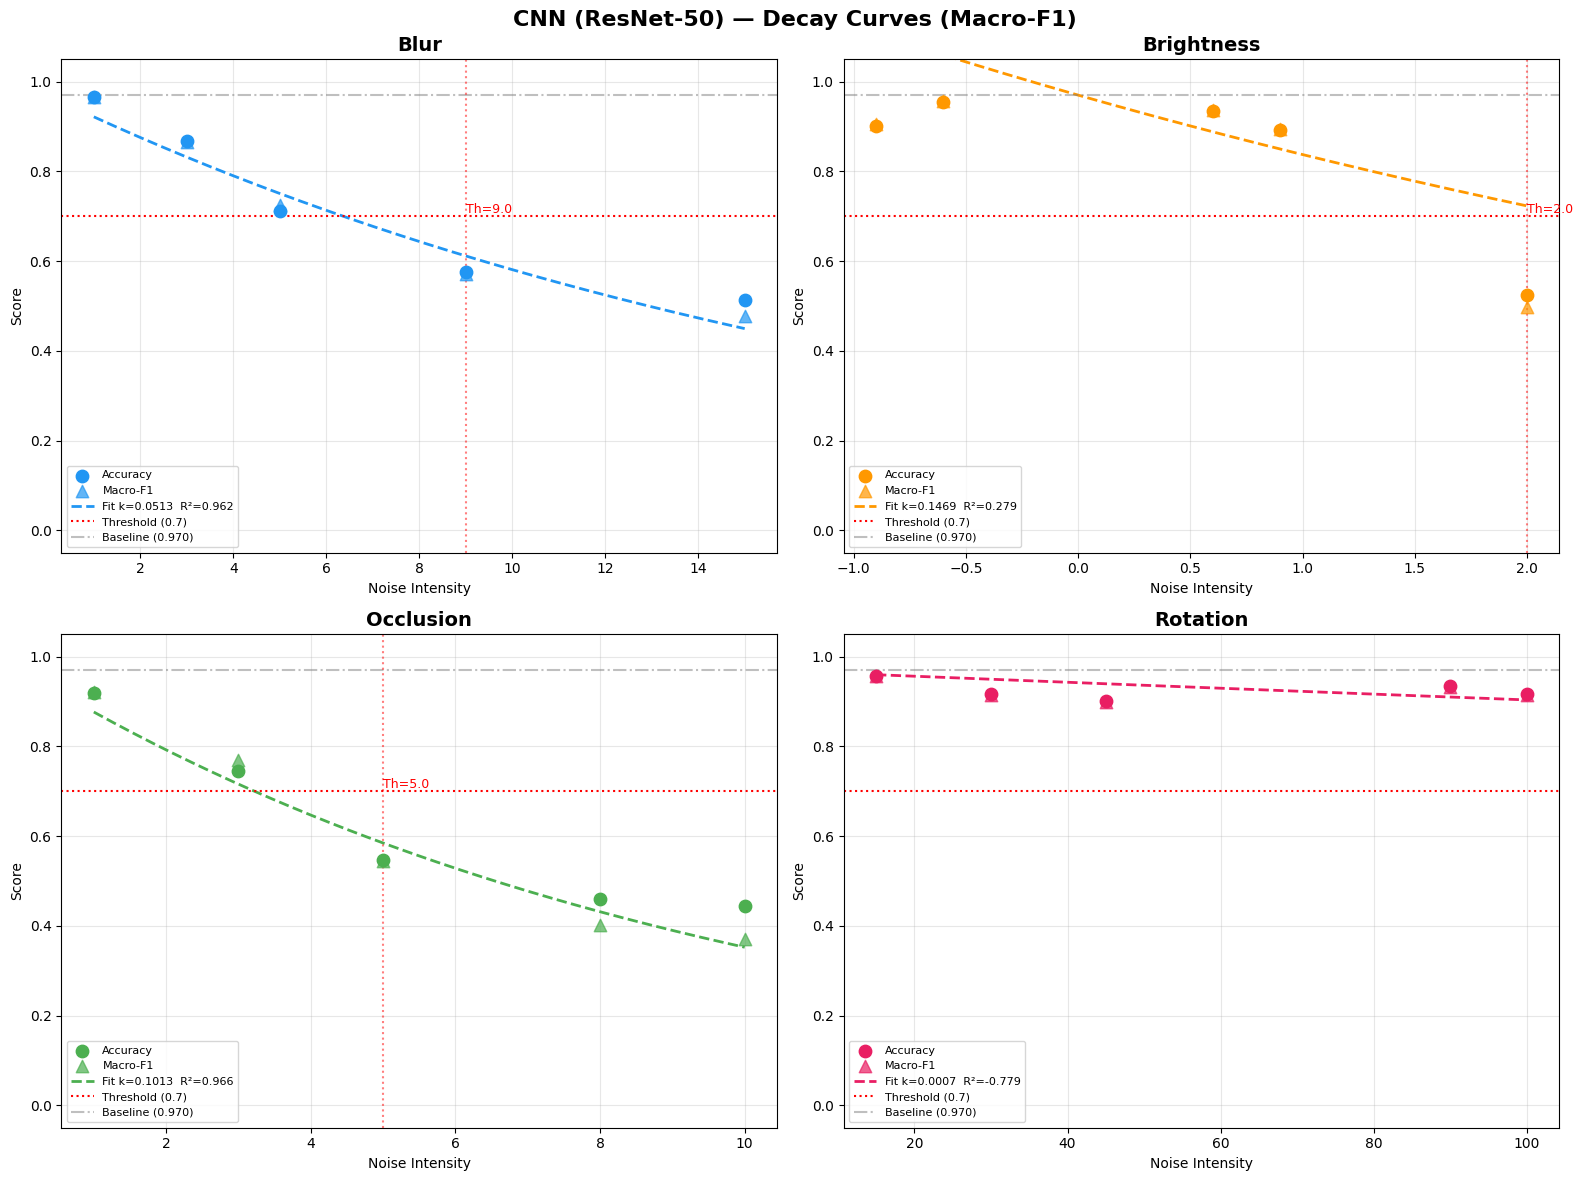

In [ ]:
COLORS = {
    'blur':       '#2196F3',
    'brightness': '#FF9800',
    'occlusion':  '#4CAF50',
    'rotation':   '#E91E63',
}

noise_list = list(df_results['Noise'].unique())
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('CNN (ResNet-50) — Decay Curves (Macro-F1)', fontsize=16, fontweight='bold')

for idx, noise in enumerate(noise_list):
    ax = axes[idx // 2, idx % 2]
    df_n = df_results[df_results['Noise'] == noise].sort_values('Intensity')
    I  = df_n['Intensity'].values.astype(float)
    Ac = df_n['Accuracy'].values.astype(float)
    Mf = df_n['Macro_F1'].values.astype(float)
    color = COLORS[noise]

    ax.scatter(I, Ac, color=color, s=80, zorder=5, label='Accuracy')
    ax.scatter(I, Mf, color=color, s=80, marker='^', alpha=0.7, zorder=5, label='Macro-F1')

    params = decay_params[noise]
    if params['k'] is not None and params['k'] > 0:
        I_s = np.linspace(min(I), max(I), 200)
        fit = A0_macro_f1 * np.exp(-params['k'] * I_s)
        ax.plot(I_s, fit, color=color, linewidth=2, linestyle='--',
                label=f"Fit k={params['k']:.4f}  R²={params['R2']:.3f}")

    ax.axhline(y=THRESHOLD, color='red', linestyle=':', linewidth=1.5,
               label=f'Threshold ({THRESHOLD})')
    ax.axhline(y=A0_macro_f1, color='gray', linestyle='-.', alpha=0.5,
               label=f'Baseline ({A0_macro_f1:.3f})')

    th = critical_thresholds.get(noise)
    if th is not None:
        ax.axvline(x=th, color='red', linestyle=':', alpha=0.5)
        ax.annotate(f'Th={th}', xy=(th, THRESHOLD), fontsize=9, color='red',
                    ha='left', va='bottom')

    ax.set_title(noise.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Noise Intensity')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_decay_curves.png', dpi=150, bbox_inches='tight')
plt.show()

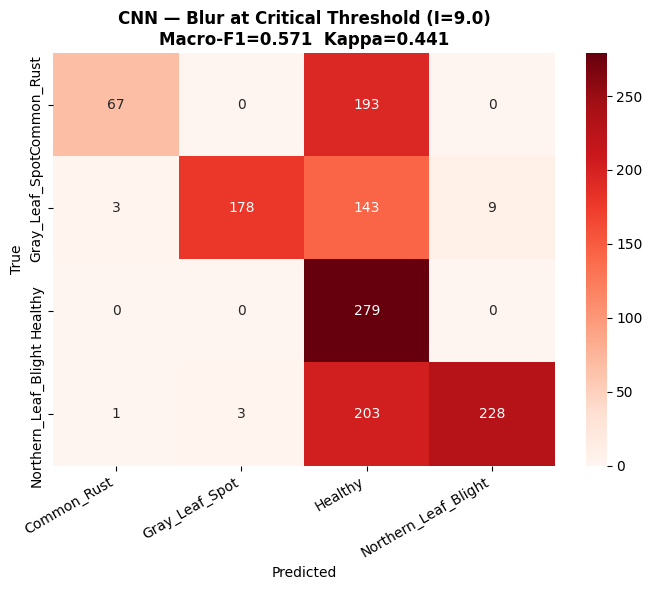

blur I=9.0: Macro-F1=0.5712, Kappa=0.4412



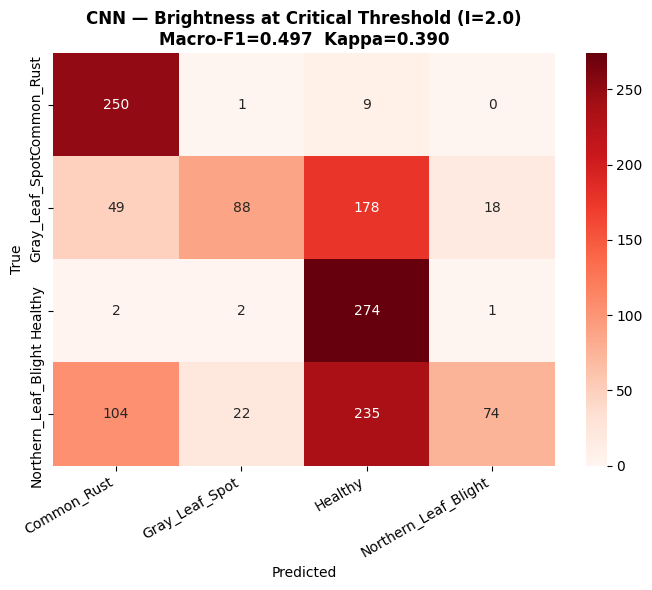

brightness I=2.0: Macro-F1=0.4972, Kappa=0.3901



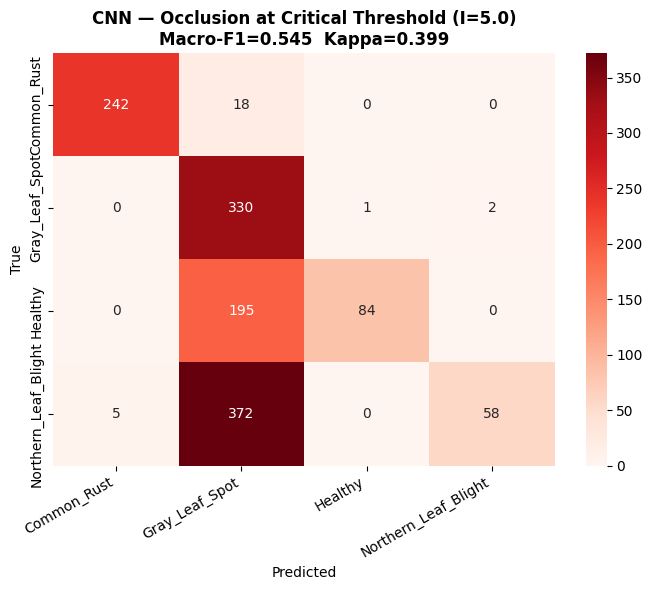

occlusion I=5.0: Macro-F1=0.5448, Kappa=0.3990

rotation: never reaches threshold — skipping confusion matrix.


In [ ]:
for noise, thresh_intensity in critical_thresholds.items():
    if thresh_intensity is None:
        print(f'{noise}: never reaches threshold — skipping confusion matrix.')
        continue

    m = noise_results[noise][thresh_intensity]
    cm = np.array(m['confusion_matrix'])

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(
        f'CNN — {noise.capitalize()} at Critical Threshold (I={thresh_intensity})\n'
        f'Macro-F1={m["macro_f1"]:.3f}  Kappa={m["kappa"]:.3f}',
        fontweight='bold'
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/cnn_cm_{noise}_threshold.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{noise} I={thresh_intensity}: Macro-F1={m["macro_f1"]:.4f}, Kappa={m["kappa"]:.4f}\n')

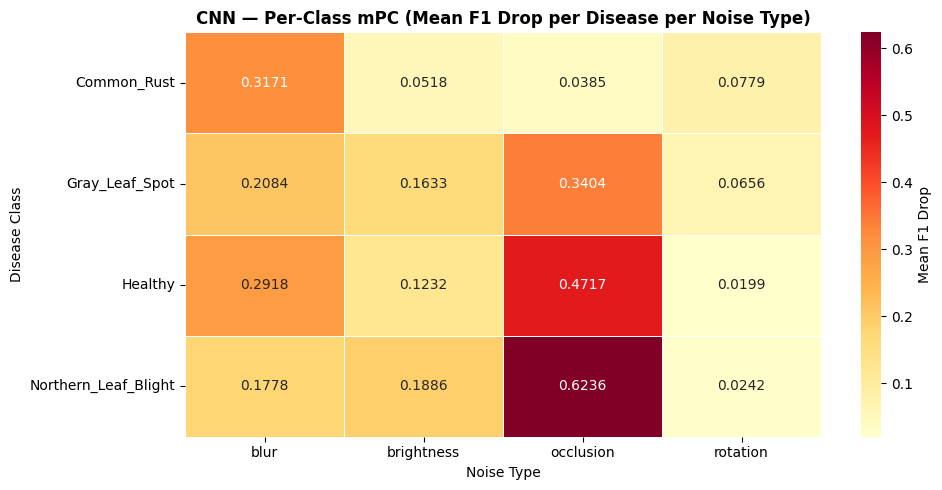


Per-class mPC table:
                        blur  brightness  occlusion  rotation
Common_Rust           0.3171      0.0518     0.0385    0.0779
Gray_Leaf_Spot        0.2084      0.1633     0.3404    0.0656
Healthy               0.2918      0.1232     0.4717    0.0199
Northern_Leaf_Blight  0.1778      0.1886     0.6236    0.0242


In [ ]:

noise_types  = list(mpc_results.keys())
heatmap_data = pd.DataFrame(
    {noise: [mpc_results[noise]['per_class_mpc'][cls] for cls in CLASS_NAMES]
     for noise in noise_types},
    index=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean F1 Drop'})
ax.set_title('CNN — Per-Class mPC (Mean F1 Drop per Disease per Noise Type)',
             fontweight='bold')
ax.set_xlabel('Noise Type')
ax.set_ylabel('Disease Class')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/cnn_perclass_mpc.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-class mPC table:')
print(heatmap_data.round(4).to_string())

In [ ]:
summary_rows = []
for noise in noise_types:
    p = decay_params[noise]
    m = mpc_results[noise]
    summary_rows.append({
        'Noise':          noise,
        'A0 (Macro-F1)':  f"{p['A0']:.4f}",
        'k (fragility)':  f"{p['k']:.4f}" if p['k'] is not None else 'N/A',
        'R²':             f"{p['R2']:.4f}" if p['R2'] is not None else 'N/A',
        'Critical Th':    critical_thresholds[noise] if critical_thresholds[noise] else 'Never',
        'mPC (Accuracy)': f"{m['mPC_accuracy']:.4f}",
        'mPC (Macro-F1)': f"{m['mPC_macro_f1']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
print('='*90)
print('CNN ROBUSTNESS SUMMARY')
print('='*90)
print(df_summary.to_string(index=False))

df_summary.to_csv('/content/drive/MyDrive/cnn_summary.csv', index=False)
print('\nSaved summary CSV to Drive.')

CNN ROBUSTNESS SUMMARY
     Noise A0 (Macro-F1) k (fragility)      R² Critical Th mPC (Accuracy) mPC (Macro-F1)
      blur        0.9703        0.0513  0.9622         9.0         0.2436         0.2488
brightness        0.9703        0.1469  0.2795         2.0         0.1285         0.1317
 occlusion        0.9703        0.1013  0.9657         5.0         0.3474         0.3686
  rotation        0.9703        0.0007 -0.7795       Never         0.0445         0.0469

Saved summary CSV to Drive.
